EDA Project Using Sales Dataset

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [8]:
df=pd.read_excel("cleaned_sales.xlsx")
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


Data Understanding

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


In [10]:
df.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [11]:
df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

Data Cleaning Phase 1

In [12]:
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Order ID'] = pd.to_numeric(df['Order ID'], errors='coerce')

C:\Users\HP\AppData\Local\Temp\ipykernel_5564\4231810945.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


Data Cleaning Phase 2

In [13]:
df=df.drop_duplicates()
df=df.dropna()

Feature Engineering Phase 1

In [14]:
df['Total Price']=df['Price Each']*df['Quantity Ordered']
df['Month']=df['Order Date'].dt.month_name()
df['Day']=df['Order Date'].dt.day_name()
df.head(1)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Total Price,Month,Day
0,176558.0,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.9,April,Friday


Insights

Month when sales was highest

In [15]:
sales_per_month=df.groupby('Month', as_index=False).agg(sales=('Total Price', 'sum'))
print("Maximum Sales was in :")
sales_per_month[sales_per_month['sales']==sales_per_month['sales'].max()]

Maximum Sales was in :


,Month,sales
2,December,4608295.7


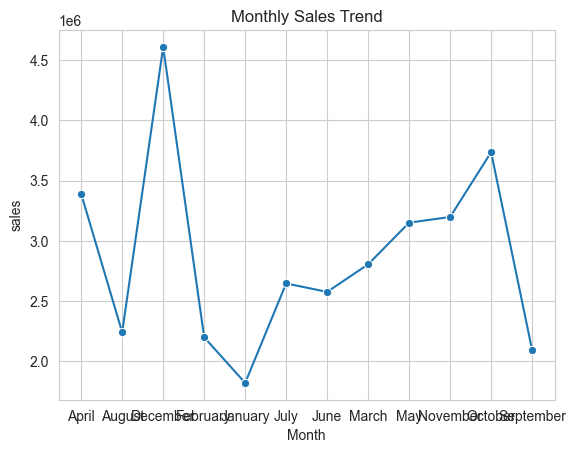

In [16]:
df["Month"] = df["Order Date"].dt.to_period("M")
sns.set_style("whitegrid")

plt.figure()

sns.lineplot(data=sales_per_month, x="Month", y="sales", marker='o')

plt.title("Monthly Sales Trend")

plt.show()

City with Highest no. of orders.

In [17]:
df[["Street","City","State_Zip"]] = df["Purchase Address"].str.split(",", expand=True)
df["City"] = df["City"].str.strip()
city=df.groupby('City',as_index=False)['Quantity Ordered'].sum()
print("HIGHEST")
city[city['Quantity Ordered']==city['Quantity Ordered'].max()]

HIGHEST


,City,Quantity Ordered
7,San Francisco,50169.0


City with lowest no. of order

In [18]:
print("LOWEST")
city[city['Quantity Ordered']==city['Quantity Ordered'].min()]

LOWEST


,City,Quantity Ordered
1,Austin,11137.0


PRODUCT WITH HIGHEST SALES.

In [19]:
product=df.groupby('Product', as_index=False)['Quantity Ordered'].count()
product[product['Quantity Ordered']==product['Quantity Ordered'].max()]

,Product,Quantity Ordered
15,USB-C Charging Cable,21859


PRODUCT WITH LOWEST SALES.

In [20]:
product[product['Quantity Ordered']==product['Quantity Ordered'].min()]

,Product,Quantity Ordered
10,LG Dryer,646
